# PRE-INGESTION EXPLORATORY EDA — AIHub 026 기술과학 분야 한–영 병렬 말뭉치

> **Notebook status:** `SUPPORTING / EXPLORATORY / PRE-INGESTION EDA / NOT G1 PASS`

| Traceability field | Value |
|---|---|
| Dataset local ID | `AIHUB_026` |
| Inspected raw path | `/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터` |
| File-family mapping | Training/Validation × KO→EN JSON; byte-identical source/label aliases |
| File hashes / source manifest | 이 notebook 실행 시 모든 physical file SHA-256과 `RAW_FILE_MANIFEST_SHA`를 계산해 아래 inventory 및 output CSV/JSON에 기록 |
| Audit timestamp | 실행 cell에서 local timezone ISO-8601로 기록 |
| Population scope | SHA-256 고유 JSON/XLSX content의 **FULL POPULATION aggregate** |
| Visualization sample | `BLAKE2b(seed=20260816) mod 1000 < 10`, 약 1%; scatter/sample preview에만 사용 |
| Raw mutation | 없음; `data/raw/**` read-only |

이 notebook은 raw 구조와 관측 분포를 시각적으로 이해하기 위한 supporting artifact다. pair validity, primary corpus 적합성, Tokenization Premium, 또는 QC acceptance를 판단하지 않는다.


## 1. 실행 환경과 snapshot contract

질문: **어떤 raw file에서 어떤 범위로 계산했는가?**

아래 cell은 worktree root를 자동 탐색하고 공용 streaming helper를 불러온다. 외부 다운로드는 없다.


In [1]:
from pathlib import Path
import json, sys
from IPython.display import Markdown, display

def find_worktree_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'outputs/eda_raw/support/raw_eda_framework.py').exists():
            return candidate
    raise FileNotFoundError('worktree root not found')

WORKTREE_ROOT = find_worktree_root(Path.cwd().resolve())
sys.path.insert(0, str(WORKTREE_ROOT / 'outputs/eda_raw/support'))
from raw_eda_framework import (
    profile_dataset, save_artifacts, plot_overview, plot_lengths,
    plot_categories, plot_quality,
)

CONFIG = {'dataset_local_id': 'AIHUB_026', 'dataset_title': 'AIHub 026 기술과학 분야 한–영 병렬 말뭉치', 'short_name': 'tech_science_parallel', 'artifact_prefix': 'aihub_026', 'raw_dir': '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터', 'mapping': 'Training/Validation × KO→EN JSON; byte-identical source/label aliases', 'category_plot_dimensions': ['domain', 'subdomain', 'source', 'source_language']}
OUTPUT_DIR = WORKTREE_ROOT / 'outputs/eda_raw' / CONFIG['artifact_prefix']
FIGURE_DIR = WORKTREE_ROOT / 'outputs/figures/eda_raw' / CONFIG['artifact_prefix']
print('WORKTREE_ROOT =', WORKTREE_ROOT)
print('Python =', sys.executable)
print('RAW =', CONFIG['raw_dir'])


WORKTREE_ROOT = /home/sieg/projects-wsl/Tokenization_Premium/.agent_worktrees/raw-eda
Python = /home/sieg/projects-wsl/Tokenization_Premium/.venv/bin/python
RAW = /home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터


## 2. Full-population streaming profile

질문: **전체 모집단의 규모·스키마·결측·길이·category·noise·중복 신호는 무엇인가?**

- JSON은 top-level `data[]`를 순차 파싱한다.
- XLSX는 `openpyxl(read_only=True)`로 행을 순차 처리한다.
- byte-identical source/label copies는 inventory에는 남기되 내용 집계는 SHA-256당 한 번만 한다.
- audit 중 size/mtime이 달라지면 결과 저장 전에 실행을 중단한다.


In [2]:
result = profile_dataset(CONFIG)
save_artifacts(result, OUTPUT_DIR)
display(Markdown('### Snapshot summary'))
display(result['summary'])
display(Markdown('### Physical file inventory and SHA-256'))
display(result['inventory'])


### Snapshot summary

{'dataset_local_id': 'AIHUB_026',
 'dataset_title': 'AIHub 026 기술과학 분야 한–영 병렬 말뭉치',
 'audit_timestamp': '2026-08-16T14:10:14+09:00',
 'audit_completed_timestamp': '2026-08-16T14:10:49+09:00',
 'raw_dir': '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/026.기술과학 분야 한-영 번역 병렬 말뭉치 데이터',
 'physical_file_count': 4,
 'unique_content_file_count': 2,
 'profiled_unique_data_files': 2,
 'logical_record_count': 1350162,
 'sample_record_count': 13632,
 'population_scope': 'FULL POPULATION AGGREGATES over unique SHA-256 JSON/XLSX content',
 'sample_method': 'deterministic BLAKE2b(seed=20260816) hash threshold 10/1000 (~1%); scatter/sample only',
 'notebook_status': 'SUPPORTING / EXPLORATORY / PRE-INGESTION EDA / NOT G1 PASS',
 'raw_file_manifest_sha': 'da4349a648306621173d8fcde6bcc18a5c0a0dbb35211c9a36d86971186ef801',
 'stability_counts': {'STABLE_FILE': 4,
  'DOWNLOAD_IN_PROGRESS': 0,
  'PARTIAL_DOWNLOAD': 0,
  'UNKNOWN': 0}}

### Physical file inventory and SHA-256

,relative_path,bytes,mtime_epoch_ns,sha256,format,split,role,direction,duplicate_of,stability_state
0,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,1640578869,1786853904709869825,b08ea5e620cc25d23e4cd263d0146e64f1673de04d1d86...,JSON,TRAIN,LABEL,KO_TO_EN,,STABLE_FILE
1,01.데이터/1.Training/원천데이터/TS1/기술과학분야_한영_train_se...,1640578869,1786853904838202805,b08ea5e620cc25d23e4cd263d0146e64f1673de04d1d86...,JSON,TRAIN,SOURCE,KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,STABLE_FILE
2,01.데이터/2.Validation/라벨링데이터/VL1/기술과학분야_한영_valid...,205220147,1786853853476599040,7e4adc920654a3321539f214ae082e273d6a38abfe59c5...,JSON,VALID,LABEL,KO_TO_EN,,STABLE_FILE
3,01.데이터/2.Validation/원천데이터/VS1/기술과학분야_한영_valid_...,205220147,1786853853502265636,7e4adc920654a3321539f214ae082e273d6a38abfe59c5...,JSON,VALID,SOURCE,KO_TO_EN,01.데이터/2.Validation/라벨링데이터/VL1/기술과학분야_한영_valid...,STABLE_FILE


## 3. 구조·규모·coverage

질문: **어떤 file group이 corpus 규모를 구성하고, core text/metadata coverage는 어떤가?**


,group,records
0,TRAIN · KO_TO_EN,1200144
1,VALID · KO_TO_EN,150018


,group,field,records,absent,null,empty,missing_or_empty_rate,type_counts
9,TRAIN · KO_TO_EN,ner,1200144,0,1003831,0,0.836425,"{""dict"": 196313, ""null"": 1003831}"
28,VALID · KO_TO_EN,ner,150018,0,125372,0,0.835713,"{""dict"": 24646, ""null"": 125372}"
0,TRAIN · KO_TO_EN,data_set,1200144,0,0,0,0.000000,"{""string"": 1200144}"
1,TRAIN · KO_TO_EN,domain,1200144,0,0,0,0.000000,"{""string"": 1200144}"
2,TRAIN · KO_TO_EN,en,1200144,0,0,0,0.000000,"{""string"": 1200144}"
3,TRAIN · KO_TO_EN,file_name,1200144,0,0,0,0.000000,"{""string"": 1200144}"
4,TRAIN · KO_TO_EN,included_unknown_words,1200144,0,0,0,0.000000,"{""boolean"": 1200144}"
5,TRAIN · KO_TO_EN,ko,1200144,0,0,0,0.000000,"{""string"": 1200144}"
6,TRAIN · KO_TO_EN,ko_original,1200144,0,0,0,0.000000,"{""string"": 1200144}"
7,TRAIN · KO_TO_EN,license,1200144,0,0,0,0.000000,"{""string"": 1200144}"


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


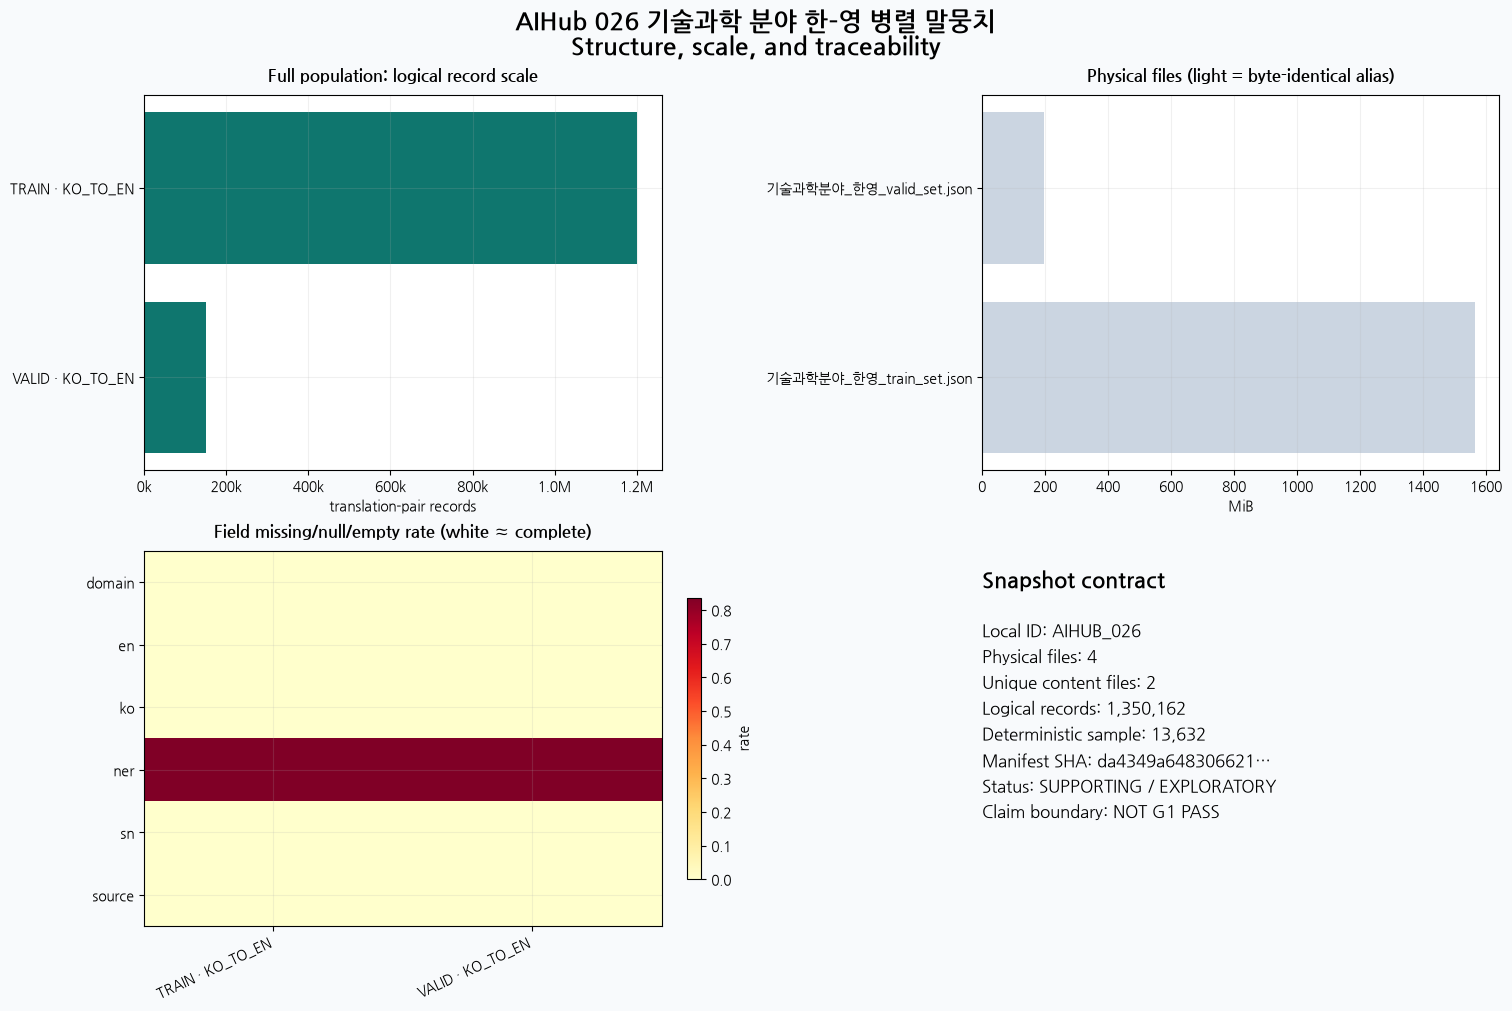

In [3]:
display(result['record_counts'].sort_values('records', ascending=False))
display(result['schema'].sort_values(['missing_or_empty_rate', 'group', 'field'], ascending=[False, True, True]).head(30))
plot_overview(result, FIGURE_DIR)


## 4. KO/EN raw length structure

질문: **raw codepoint/UTF-8 byte 길이의 중심·꼬리와 KO–EN 관계가 group별로 어떻게 다른가?**

위쪽 분포선과 p50/p95는 full population이다. hexbin만 deterministic 약 1% sample이다.


,group,language,metric,count,min,p50,p90,p95,p99,max,mean
0,TRAIN · KO_TO_EN,EN,codepoints,1200144,1,173,254,279,330,2208,178.462173
2,TRAIN · KO_TO_EN,KO,codepoints,1200144,2,77,108,116,131,684,78.093343
4,VALID · KO_TO_EN,EN,codepoints,150018,11,173,254,280,331,635,178.542182
6,VALID · KO_TO_EN,KO,codepoints,150018,7,77,108,116,131,295,78.177839
1,TRAIN · KO_TO_EN,EN,utf8_bytes,1200144,1,173,254,280,330,2208,178.504153
3,TRAIN · KO_TO_EN,KO,utf8_bytes,1200144,4,182,257,278,314,1538,186.098959
5,VALID · KO_TO_EN,EN,utf8_bytes,150018,11,173,254,280,331,635,178.586803
7,VALID · KO_TO_EN,KO,utf8_bytes,150018,19,182,257,278,315,705,186.293571


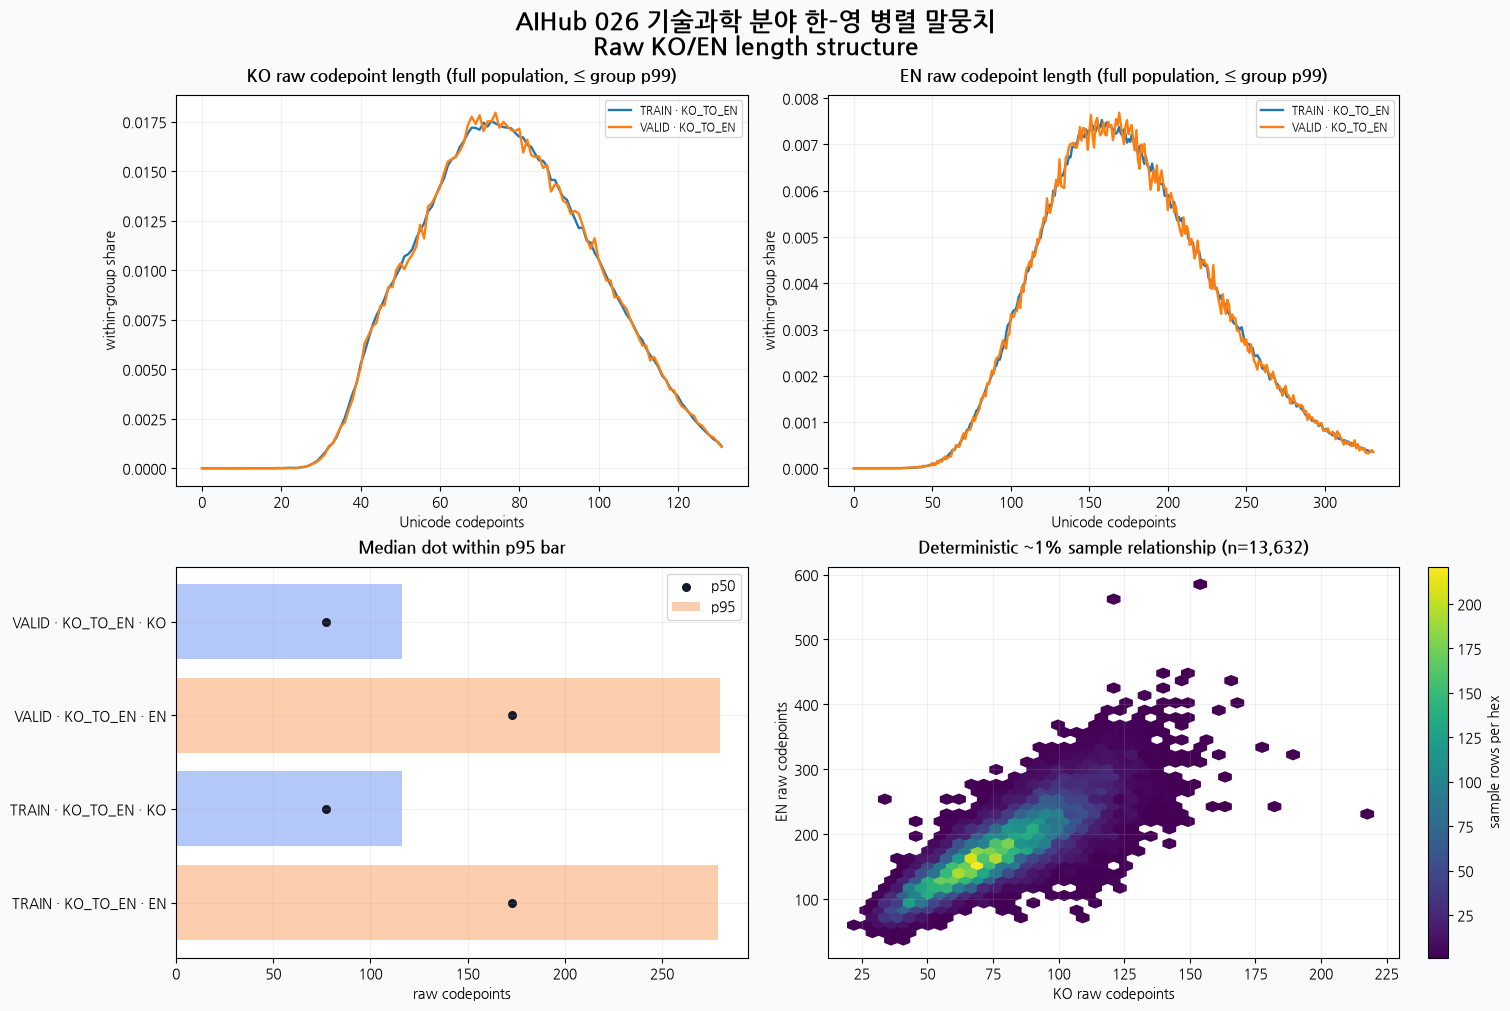

In [4]:
display(result['length_summary'].sort_values(['metric', 'group', 'language']))
plot_lengths(result, FIGURE_DIR)


## 5. Domain/source/category composition

질문: **어떤 source/domain/category가 실제 row volume을 구성하는가?**

범주 수가 큰 field는 top raw value만 시각화하며, 전체 count table은 CSV artifact로 남긴다.


,dimension,value,count
0,data_set,기술과학분야,1350162
4,domain,세계,449941
2,domain,기술과학,359910
1,domain,경제,270144
5,domain,정치,180239
3,domain,기후,89928
6,license,open,1350162
8,source,한국연구재단,990252
7,source,특허정보원,359910
9,source_language,ko,1350162


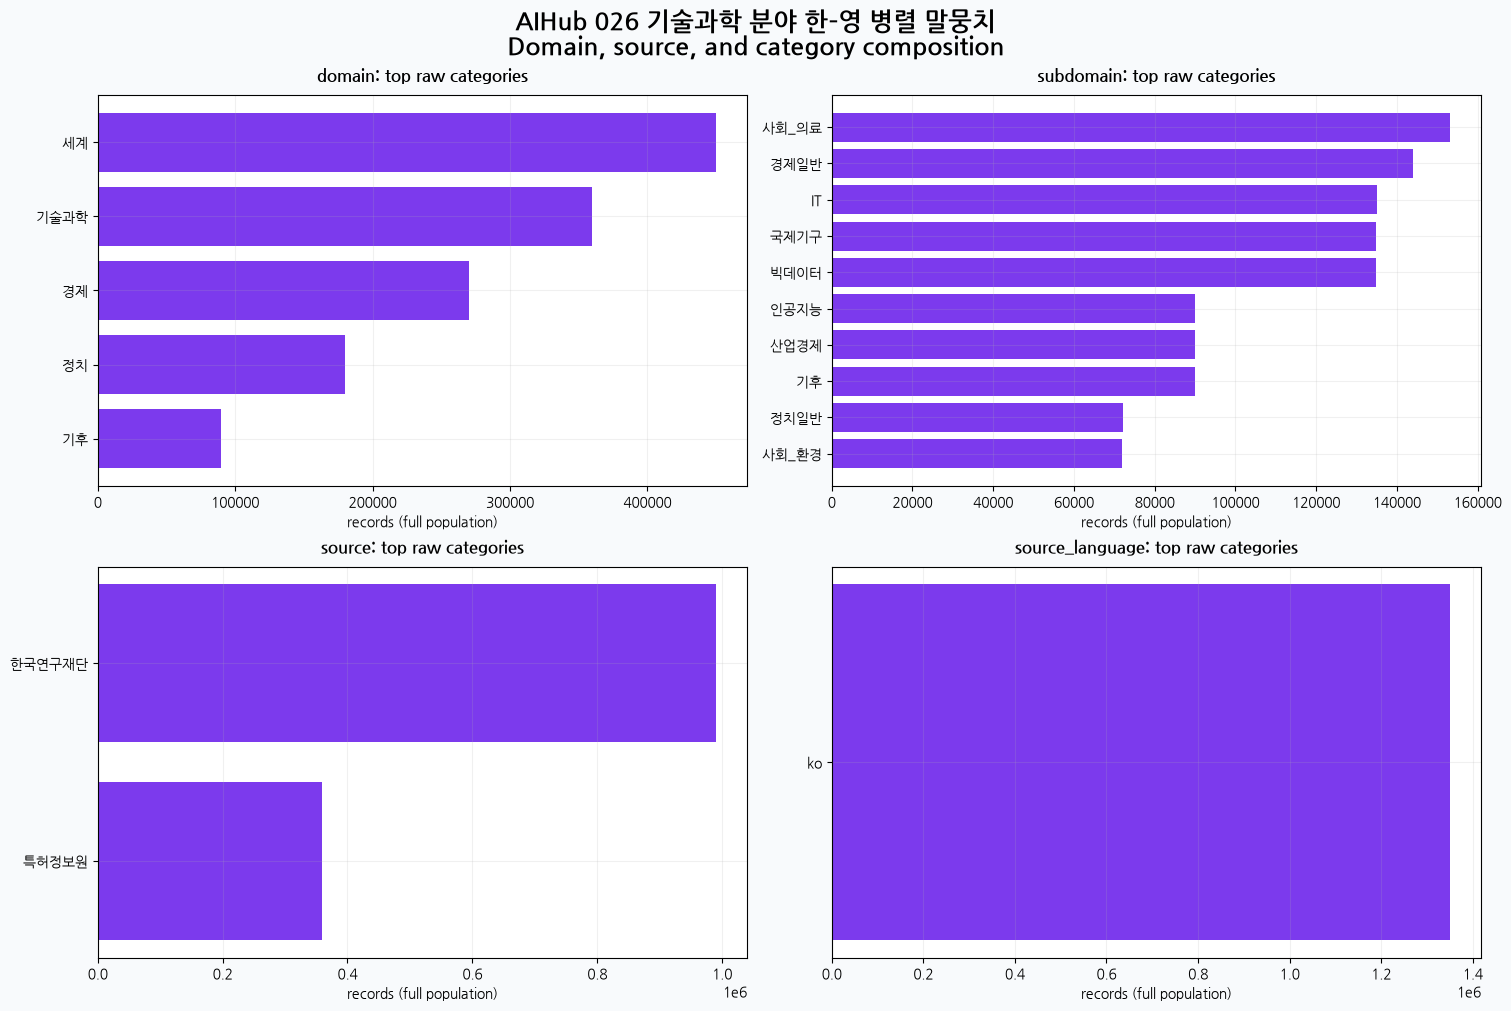

In [5]:
top_categories = (result['categories'].groupby(['dimension', 'value'], as_index=False)['count'].sum()
                  .sort_values(['dimension', 'count'], ascending=[True, False])
                  .groupby('dimension').head(10))
display(top_categories)
plot_categories(result, FIGURE_DIR)


## 6. Potential QC signals — acceptance가 아님

질문: **missing metadata, whitespace/script/markup 신호, raw duplicate 후보는 어디에 집중되는가?**

모든 항목은 `OBSERVED RAW DISTRIBUTION` 또는 `POTENTIAL QC ISSUE`다. 자동 오류 판정이나 정규화 근거가 아니다.


,scope,duplicate_pair_rows_after_first,distinct_duplicate_pair_hashes,validation_rows_overlapping_training_pair,candidate_method
0,dataset,44,44,9,BLAKE2b-64 raw KO+EN; collision possible; no n...


,group,language,metric,row_count,records,rows_per_100k
5,TRAIN · KO_TO_EN,KO,cross_script,328005,1200144,27330.470344
15,VALID · KO_TO_EN,KO,cross_script,40813,150018,27205.402018
14,VALID · KO_TO_EN,EN,zero_width,840,150018,559.932808
4,TRAIN · KO_TO_EN,EN,zero_width,6688,1200144,557.266461
2,TRAIN · KO_TO_EN,EN,html_like,445,1200144,37.078884
12,VALID · KO_TO_EN,EN,html_like,51,150018,33.995920
10,VALID · KO_TO_EN,EN,cross_script,24,150018,15.998080
0,TRAIN · KO_TO_EN,EN,cross_script,151,1200144,12.581824
7,TRAIN · KO_TO_EN,KO,html_like,67,1200144,5.582663
16,VALID · KO_TO_EN,KO,expected_script_absent,5,150018,3.332933


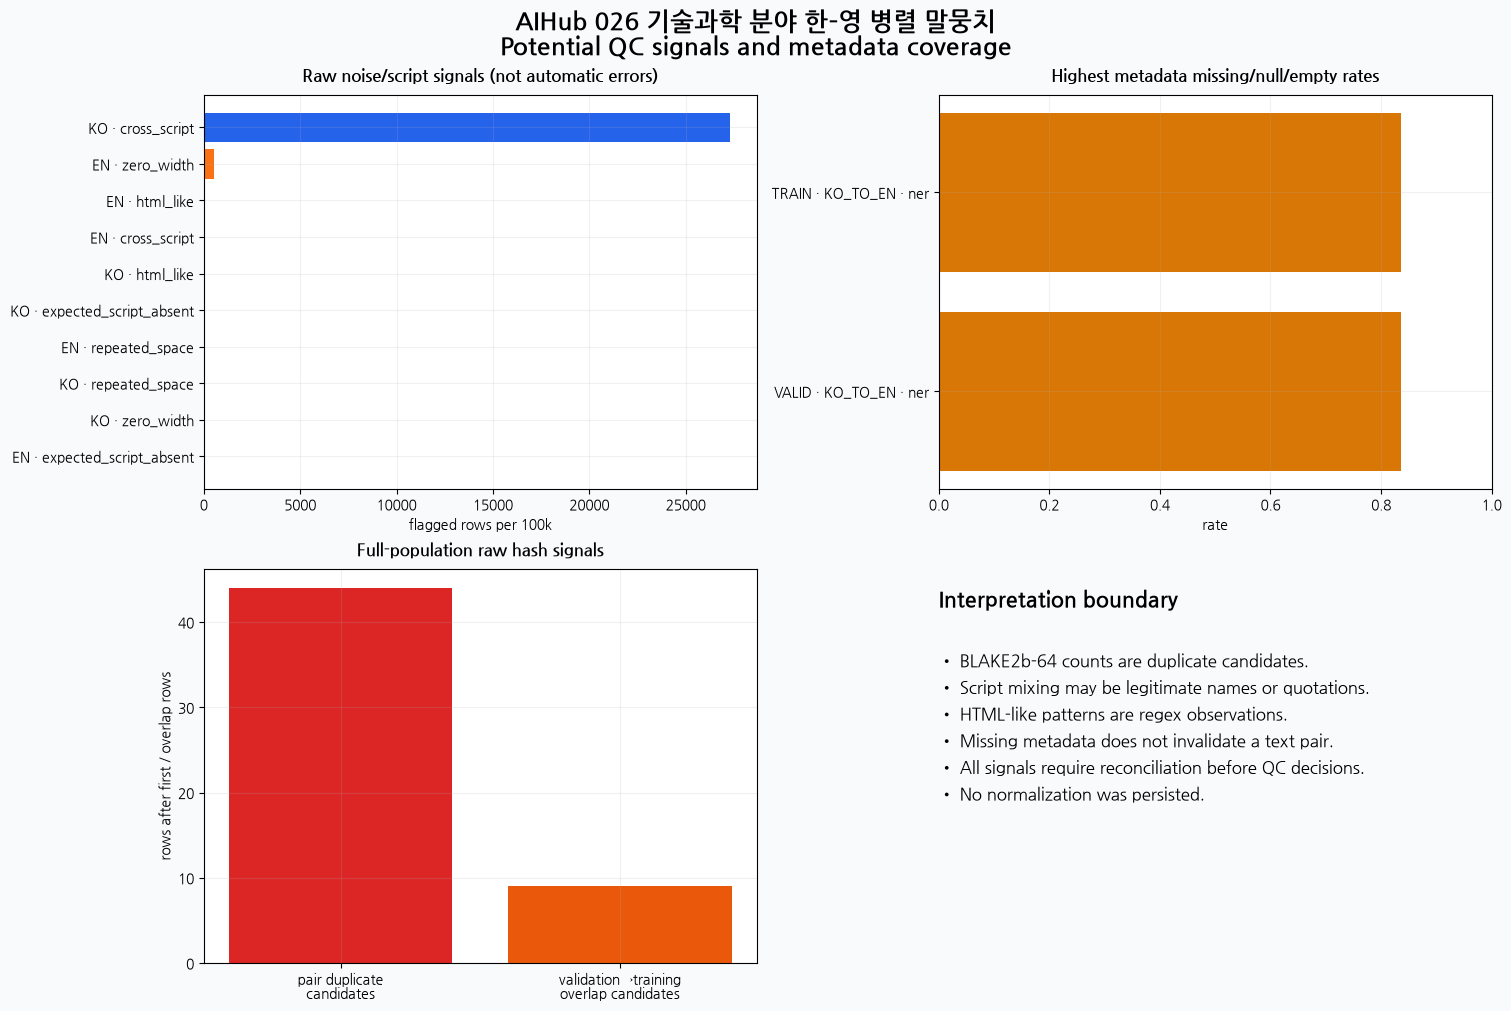

In [6]:
display(result['duplicates'])
display(result['noise'].sort_values('rows_per_100k', ascending=False).head(30))
plot_quality(result, FIGURE_DIR)


## 7. Deterministic sample structure

질문: **집계표 뒤의 실제 row 구조가 어떤 모습인가?**

아래 preview는 scatter와 동일한 deterministic hash sample 중 일부다. `ko_preview`/`en_preview`는 표시 길이를 160 codepoint로 제한하며 원문을 수정하지 않는다.


In [7]:
sample_columns = [c for c in ['group','relative_path','row_number','pair_key','ko_preview','en_preview','ko_codepoints','en_codepoints','domain','subdomain','source','대분류','소분류','상황','언론사','키워드','지자체'] if c in result['samples'].columns]
display(result['samples'][sample_columns].head(12))
print(f"sample rows = {len(result['samples']):,}; full logical records = {result['summary']['logical_record_count']:,}")


,group,relative_path,row_number,pair_key,ko_preview,en_preview,ko_codepoints,en_codepoints,domain,subdomain,source
0,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,128,WRN030618095734778642,지난주 본 준비회의에서 멕시코가 내놓은 '그린 펀드' 제안도 지지를 얻고 있다.,"Mexico's proposal for a ""green fund"" at last w...",44,97,세계,사회_환경,한국연구재단
1,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,333,KITS01A125055,"자기장 생성부(145)는 촉각부(141)와 대응되는 위치 및 형상을 가지며, 자기장...",The magnetic field generating unit 145 has a p...,127,314,기술과학,IT,특허정보원
2,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,339,KBDS01A70275,장면 조건 센서(520)의 다른 예는 물체까지의 거리 또는 위치의 측정치를 결정하는...,Another example of a scene condition sensor 52...,71,156,기술과학,빅데이터,특허정보원
3,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,357,ECS2710618094527181544,"해외 직판 업체들은 자사 설계 및 생산 위탁(OEM), 국산 완제품 소싱, 직접 생...",Overseas direct sales companies are mainly usi...,93,219,경제,국제통상,한국연구재단
4,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,416,KBDS01A89778,"데이터의 처리는 사용자 정의에 의해 생성된 중간 프로세스에 의해 각각 수행되며, 프...",The processing of data is performed by interme...,96,194,기술과학,빅데이터,특허정보원
5,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,533,POS0920618100353942576,AAA의 방어 계획은 위 훈령이 하달되기 이전 시점에 아무르 군관구 참모부로 발송되었다.,AAA's defense plan was sent to Amur Military D...,49,104,정치,북한,한국연구재단
6,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,584,WRN020618095717627743,11일 인도 언론에 따르면 뉴델리에선 올해 들어 지금까지 뎅기열 환자가 255명 보...,"According to Indian media reports on the 11th,...",73,163,세계,사회_의료,한국연구재단
7,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,633,POS18720618095939873739,집단 간의 이념적 거리보다는 집단 내의 결집(또는 분산의 약화)의 강도로서 측정될 ...,It is said that the polarization phenomenon as...,109,248,정치,국방외교,한국연구재단
8,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,767,POS0120618095841858186,이 연구들은 발표된 지가 오래되어서 최신 연구 성과를 수용하지 못했다는 점과 전적으...,Since these research reports have already been...,95,204,정치,국방외교,한국연구재단
9,TRAIN · KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL1/기술과학분야_한영_train_s...,805,POS0920618100156910071,"분석을 통하여 북한 기록영화에서 의미가 어떻게 생성되고, 나아가 그것이 내포하고 있...","Through the evaluation, how definition is done...",61,135,정치,북한,한국연구재단


sample rows = 13,632; full logical records = 1,350,162


## 8. Interpretation scaffold

**Target 설계:** 이 supporting EDA에는 modeling target이 없다. 관찰 단위는 raw KO–EN pair와 file/group metadata다.

**관찰:** 실행 결과의 full-population tables와 네 개 figure에서 규모, 길이, 범주, 결측/noise 위치를 확인한다.

**원인 가설:** source, domain, 번역 방향, 문체, file generation 방식이 분포 차이에 관련될 수 있으나 이 notebook은 원인을 검정하지 않는다.

**제한:** deterministic sample plot은 모집단 aggregate가 아니며, 64-bit hash duplicate count에는 collision 가능성이 있다. 외부 AIHub 문서와 공식 release completeness는 확인하지 않는다.

**결론:** `OBSERVED RAW DISTRIBUTION`, `STRUCTURAL DATA CHARACTERISTIC`, `POTENTIAL QC ISSUE`, `REQUIRES RECONCILIATION` 범위에서만 해석한다. **NOT G1 PASS.**
